In [18]:
# ===== 셀 1: 라이브러리 =====
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

print('라이브러리 불러오기 완료!')

라이브러리 불러오기 완료!


In [19]:
# ===== 셀 2: 데이터 불러오기 =====
data_dir = os.path.join(os.getenv('HOME'), 'work/aiffel_test/Data_Analysis/DA02')

train_data_path = os.path.join(data_dir, 'train.csv')
sub_data_path = os.path.join(data_dir, 'test.csv')

data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)

print('train data dim :', data.shape)
print('test data dim :', sub.shape)
data.head()

train data dim : (15035, 21)
test data dim : (6468, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [20]:
# ===== 셀 3: 데이터 정보 확인 =====
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15035 non-null  int64  
 1   date           15035 non-null  object 
 2   price          15035 non-null  float64
 3   bedrooms       15035 non-null  int64  
 4   bathrooms      15035 non-null  float64
 5   sqft_living    15035 non-null  int64  
 6   sqft_lot       15035 non-null  int64  
 7   floors         15035 non-null  float64
 8   waterfront     15035 non-null  int64  
 9   view           15035 non-null  int64  
 10  condition      15035 non-null  int64  
 11  grade          15035 non-null  int64  
 12  sqft_above     15035 non-null  int64  
 13  sqft_basement  15035 non-null  int64  
 14  yr_built       15035 non-null  int64  
 15  yr_renovated   15035 non-null  int64  
 16  zipcode        15035 non-null  int64  
 17  lat            15035 non-null  float64
 18  long  

In [21]:
# ===== 셀 4: 결측치 확인 =====
print(data.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


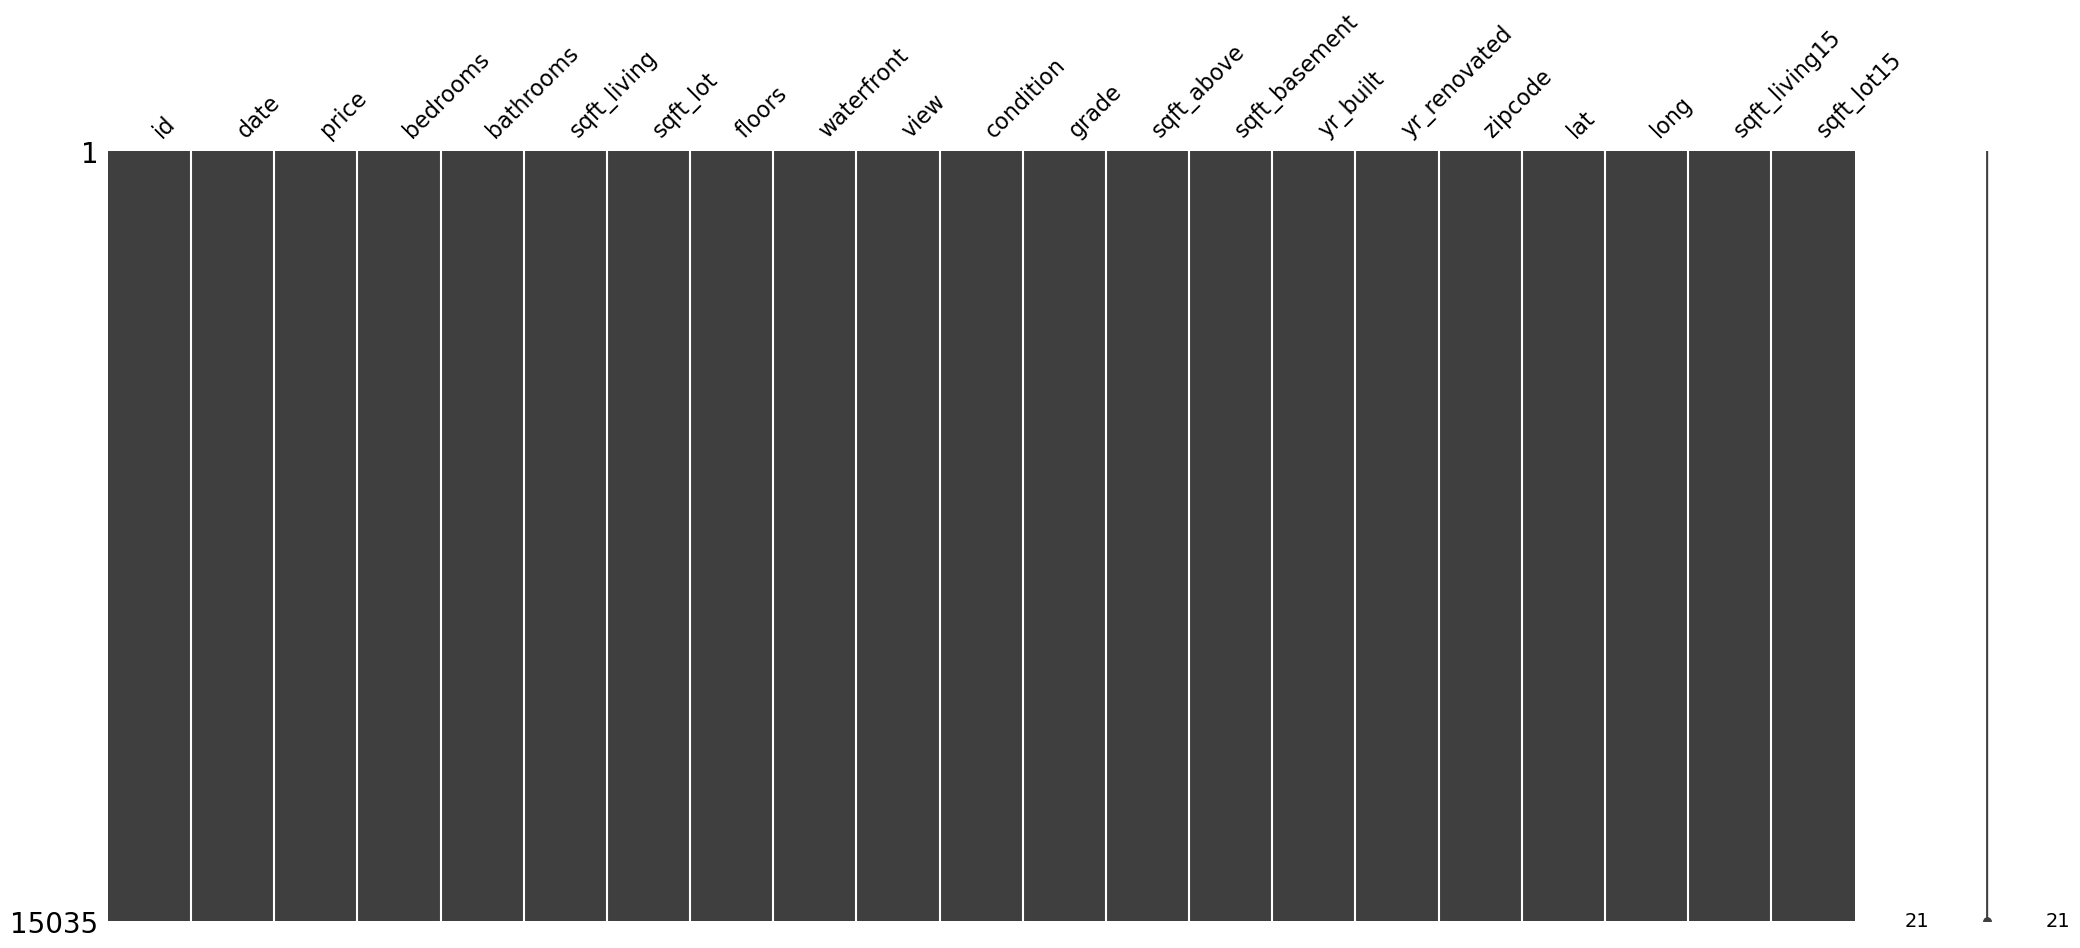

In [22]:
# ===== 셀 5: 결측치 시각화 =====
msno.matrix(data)
plt.show()

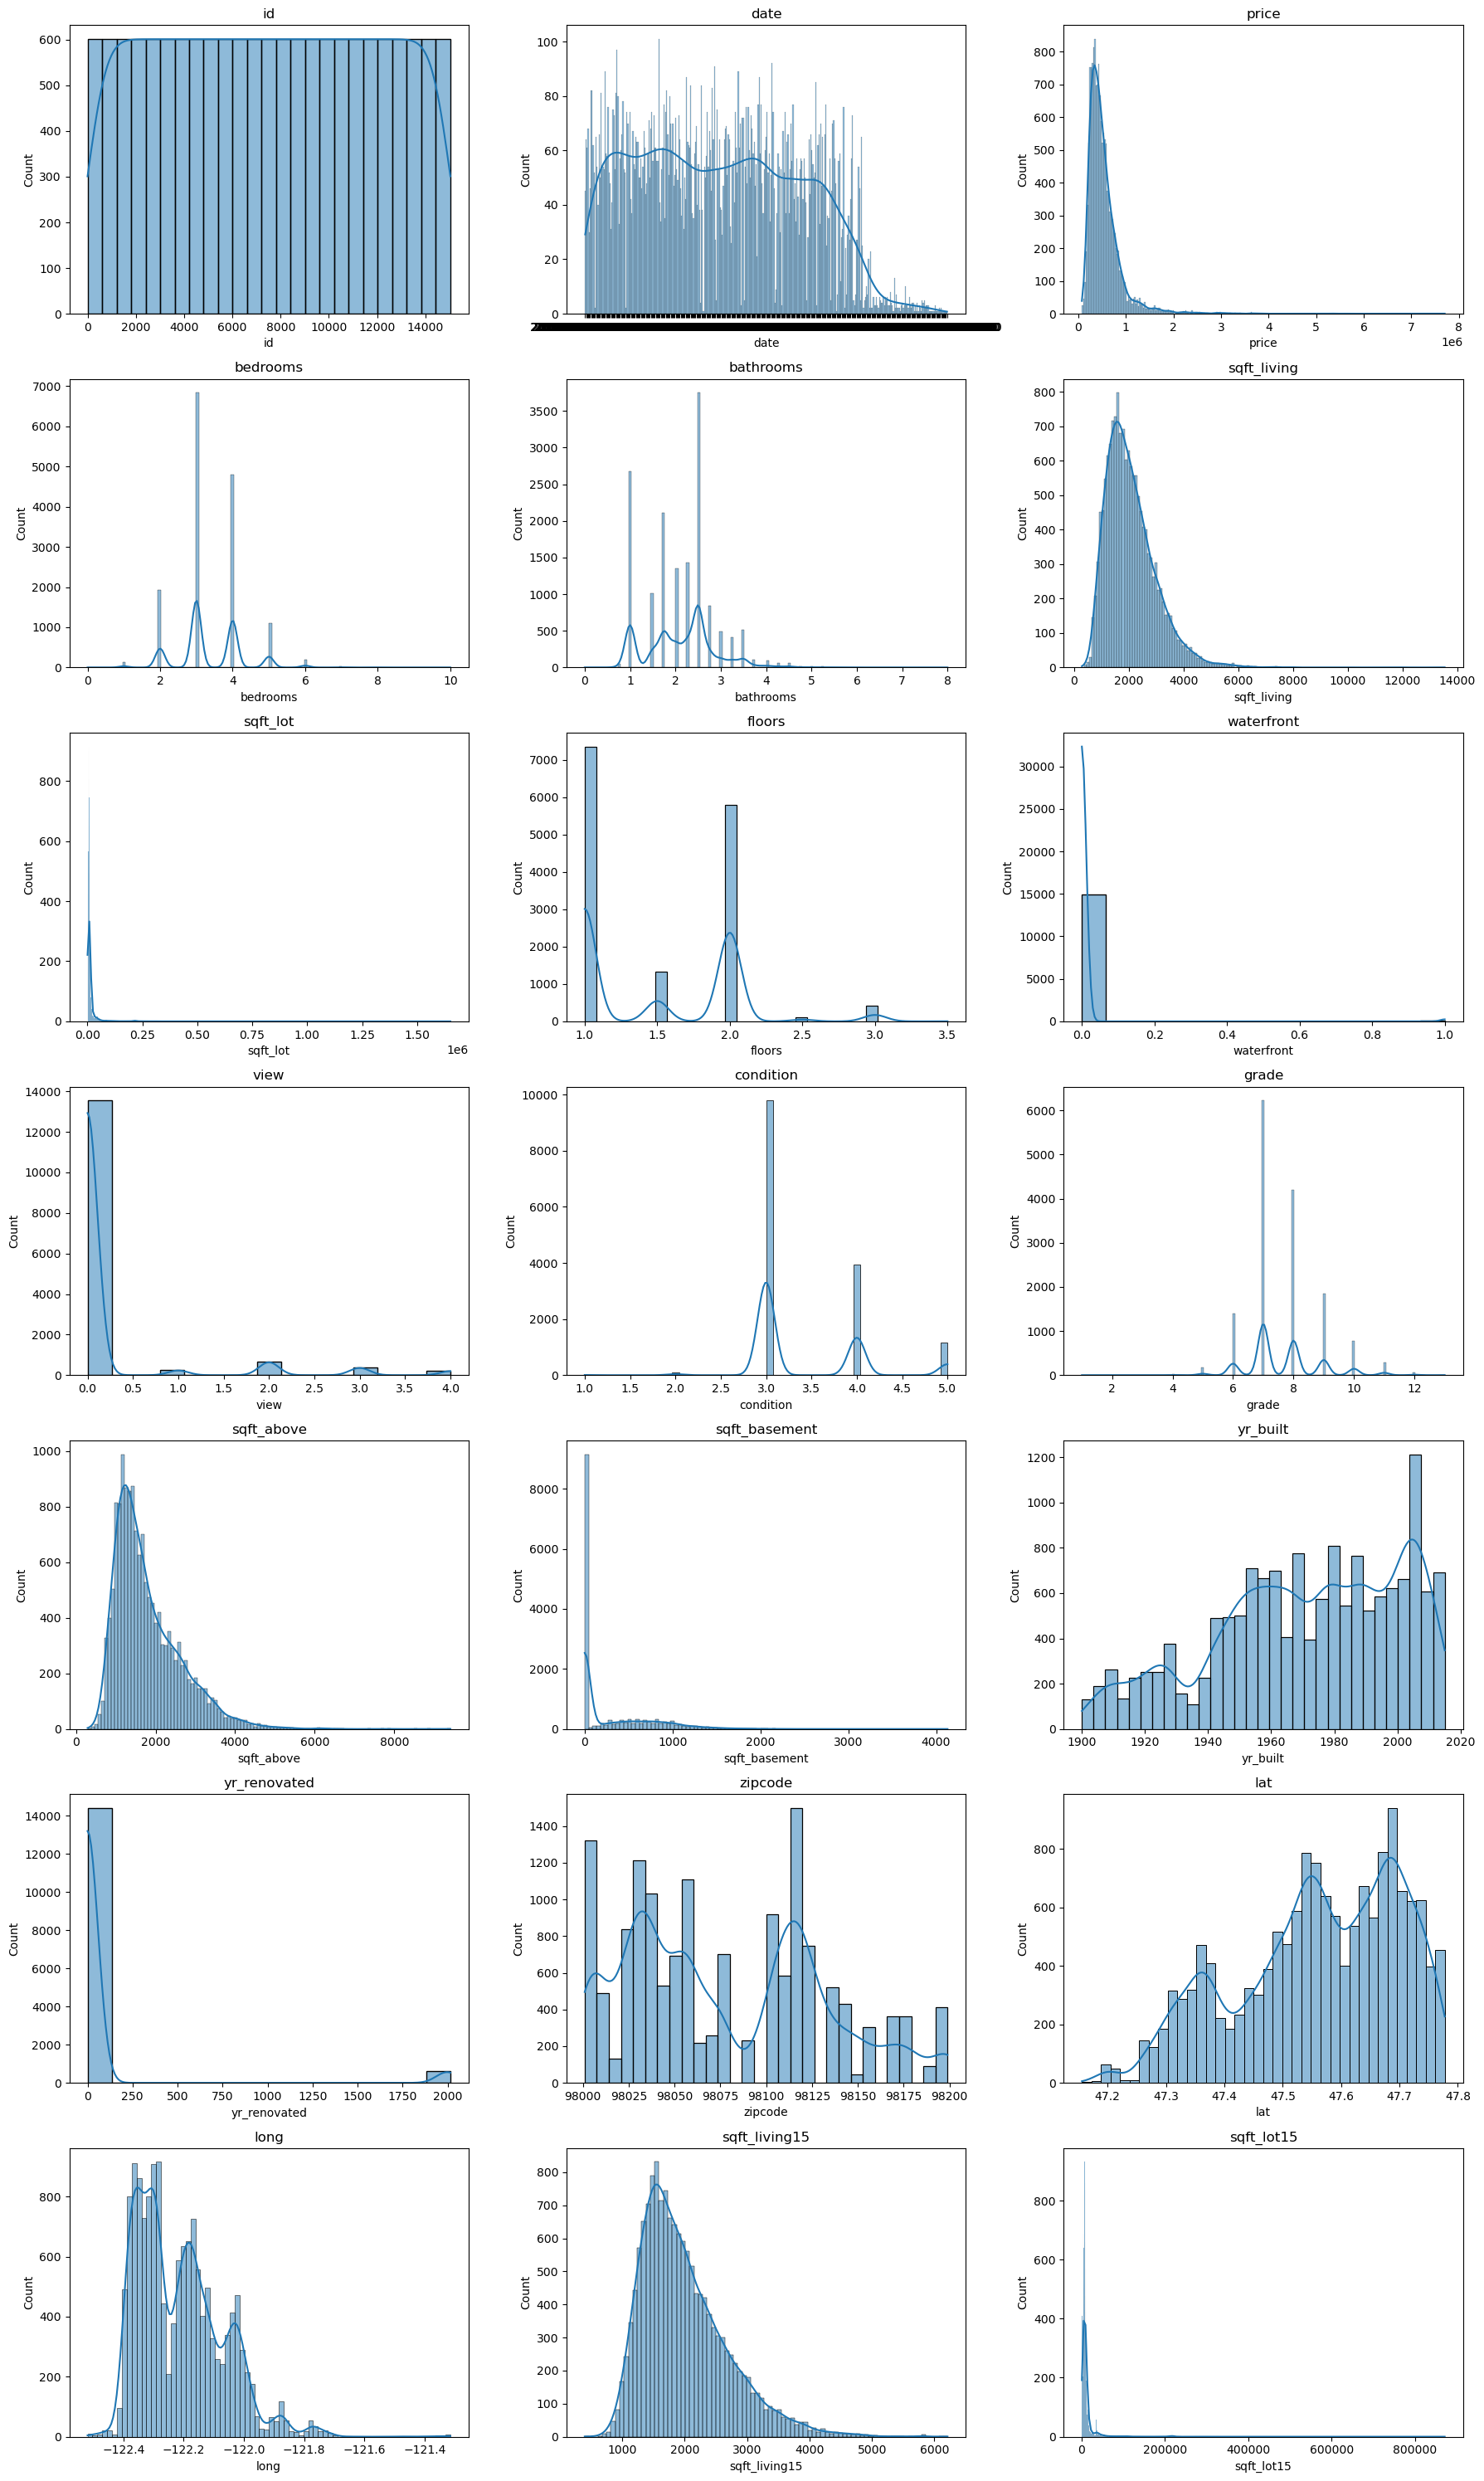

In [23]:
# ===== 셀 6: 데이터 분포 시각화 =====
fig, axes = plt.subplots(7, 3, figsize=(18, 30))
columns = data.columns
for i, ax in enumerate(axes.flatten()):
    if i < len(columns):
        sns.histplot(data[columns[i]], kde=True, ax=ax)
        ax.set_title(columns[i])
    else:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
# ===== 셀 7: train + test 합치기 (전처리 동일 적용 위해) =====
train_len = len(data)
data = pd.concat((data, sub), axis=0)
print('합친 데이터 크기:', data.shape)

합친 데이터 크기: (21503, 21)


In [25]:
# ===== 셀 8: 전처리 - date 제거, id 제거 =====
# date → 문자열이라 모델이 못 읽음
# id → 그냥 번호라 학습에 쓸모없음
data = data.drop(['date', 'id'], axis=1)
print('전처리 후:', data.shape)
data.head()

전처리 후: (21503, 19)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


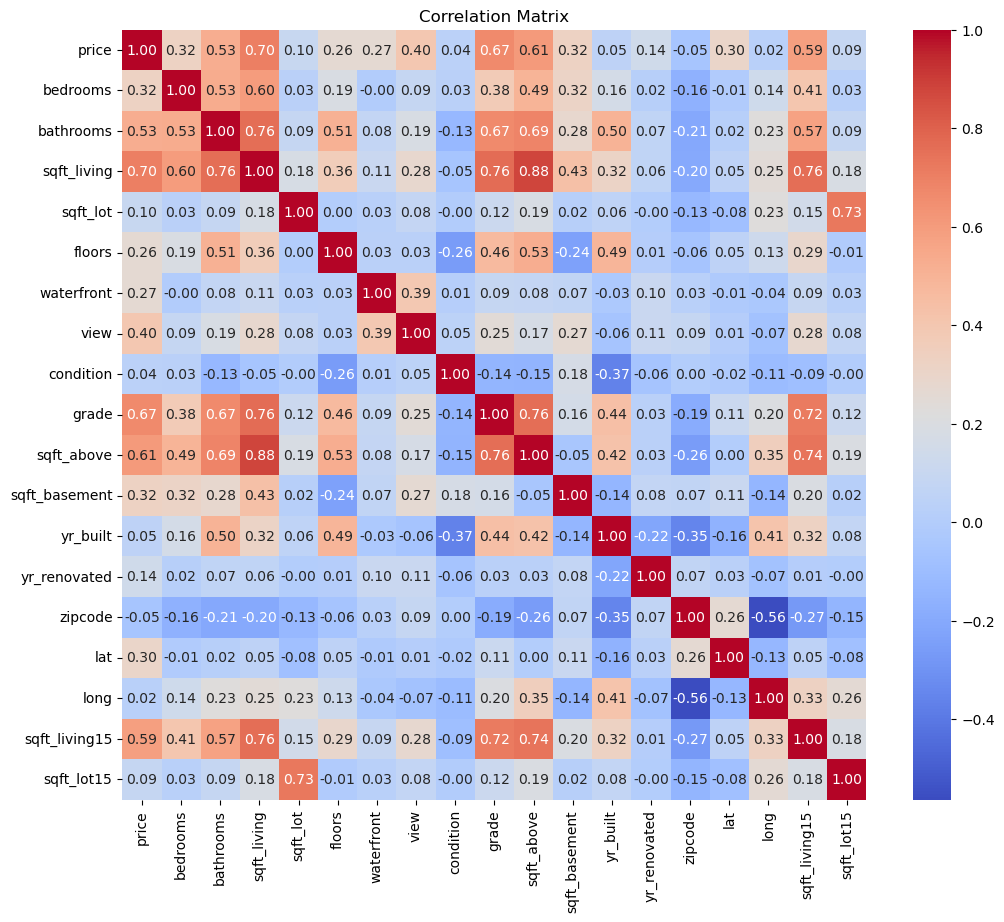

In [26]:
# ===== 셀 9: 상관관계 히트맵 =====
corrmat = data[:train_len].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corrmat, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [27]:
# ===== 셀 10: price와 상관관계 높은 feature 확인 =====
k = 10
cols = corrmat.nlargest(k, 'price')['price'].index
print('price와 상관관계 높은 컬럼들:')
print(cols.tolist())

price와 상관관계 높은 컬럼들:
['price', 'sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'bedrooms', 'sqft_basement', 'lat']


In [28]:
# ===== 셀 11: X, y 분리 (★ 가장 중요한 셀!) =====
# train과 test를 다시 나눔
train = data[:train_len]
test = data[train_len:]

# y = 예측할 정답 (집 가격) → train에서만!
y = train['price']
y_log = np.log1p(y)  # log 변환 (편차 줄이기)

# x = 입력 특성 → price 제거
x = train.drop('price', axis=1)

# test 데이터 (제출용)
x_sub = test.drop('price', axis=1)

# ★ NaN 확인 (반드시 0이어야 함!)
print('y_log NaN 개수:', y_log.isnull().sum())
print('x NaN 개수:', x.isnull().sum().sum())
print('x shape:', x.shape)
print('y_log shape:', y_log.shape)
print('x_sub shape:', x_sub.shape)

y_log NaN 개수: 0
x NaN 개수: 0
x shape: (15035, 18)
y_log shape: (15035,)
x_sub shape: (6468, 18)


In [29]:
# ===== 셀 12: RMSE 함수 정의 =====
def rmse(y_test, y_pred):
    return np.sqrt(np.mean((y_test - y_pred) ** 2))

In [30]:
# ===== 셀 13: 3가지 모델 준비 =====
random_state = 2024

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = xgb.XGBRegressor(random_state=random_state)
lightgbm = lgb.LGBMRegressor(random_state=random_state, verbose=-1)

models = [
    {'model': gboost, 'name': 'GradientBoosting'},
    {'model': xgboost, 'name': 'XGBoost'},
    {'model': lightgbm, 'name': 'LightGBM'},
]

In [31]:
# ===== 셀 14: 개별 모델 성능 확인 =====
df = {}
for model_info in models:
    model = model_info['model']
    model_name = model_info['name']

    X_train, X_test, y_train, y_test = train_test_split(
        x, y_log, random_state=random_state, test_size=0.2
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    df[model_name] = rmse(y_test, y_pred)
    print(f'{model_name} RMSE: {rmse(y_test, y_pred):.4f}')

result_df = pd.DataFrame(df, index=['RMSE'])
print(result_df)

GradientBoosting RMSE: 0.1806
XGBoost RMSE: 0.1675
LightGBM RMSE: 0.1642
      GradientBoosting   XGBoost  LightGBM
RMSE          0.180618  0.167499  0.164239


In [32]:
# ===== 셀 15: 교차 검증 (Cross Validation) =====
def get_cv_score(models):
    kfold = KFold(n_splits=5, shuffle=True, random_state=random_state)
    for m in models:
        CV_score = np.mean(cross_val_score(
            m['model'], X=x.values, y=y_log.values, cv=kfold
        ))
        print(f"Model: {m['name']}, CV score: {CV_score:.4f}")

get_cv_score(models)

Model: GradientBoosting, CV score: 0.8783
Model: XGBoost, CV score: 0.8930
Model: LightGBM, CV score: 0.9001


In [33]:
# ===== 셀 16: 앙상블 - 전체 데이터로 학습 =====
gboost.fit(x, y_log)
xgboost.fit(x, y_log)
lightgbm.fit(x, y_log)

# test 데이터에 대해 각각 예측
pred_gboost = gboost.predict(x_sub)
pred_xgboost = xgboost.predict(x_sub)
pred_lightgbm = lightgbm.predict(x_sub)

print('예측 완료!')

예측 완료!


In [40]:
# ===== 셀 17: 제출 파일 생성 =====
save_path = os.path.join(os.getenv('HOME'), 'work/aiffel_test/Data_Analysis/DA02/submission.csv')

sub_result = pd.DataFrame({
    'id': pd.read_csv(sub_data_path)['id'],
    'price': final_pred
})

sub_result.to_csv(save_path, index=False)

# 확인
check = pd.read_csv(save_path)
print(check.columns.tolist())
print(check.shape)
print(check.head())

['id', 'price']
(6468, 2)
      id         price
0  15035  5.058528e+05
1  15036  4.547058e+05
2  15037  1.332633e+06
3  15038  2.896364e+05
4  15039  3.150336e+05


In [41]:
# 확인용 - 이걸 실행해서 컬럼 체크!
check = pd.read_csv('submission.csv')
print(check.columns.tolist())  # ['id', 'price'] 만 나와야 함!
print(check.head())

['id', 'price']
      id         price
0  15035  5.058528e+05
1  15036  4.547058e+05
2  15037  1.332633e+06
3  15038  2.896364e+05
4  15039  3.150336e+05


In [42]:
save_path = os.path.join(os.getenv('HOME'), 'work/aiffel_test/Data_Analysis/DA02/submission.csv')

sub_result = pd.DataFrame({
    'id': pd.read_csv(sub_data_path)['id'],
    'price': final_pred
})

sub_result.to_csv(save_path, index=False)

# 확인
check = pd.read_csv(save_path)
print(check.columns.tolist())
print(check.shape)
print(check.head())

['id', 'price']
(6468, 2)
      id         price
0  15035  5.058528e+05
1  15036  4.547058e+05
2  15037  1.332633e+06
3  15038  2.896364e+05
4  15039  3.150336e+05


In [ ]:
work/aiffel_test/Data_Analysis/DA02/score.png